# **Seasonal Agricultere Performance Analysis**
## Major Data Analytics Project




**Domain:** Agriculture

**Project Theme:** Seasonal Agriculture Performance

**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn

## Project Goal

Investigate how agricultural performance varies accross seasson and identify meaningful patterns, trends, relationship and differences in the avalible data.


#1. Problem Statement
Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.


#2.Project Objectives
 Explore and understand the dataset.

 Clean and prepare the data for analysis.

 Examine how agricultural performance varies across seasons.

 Identify important seasonal patterns and trends.

 Investigate relationships between seasonal conditions and agricultural outcomes.

 Compare relevant groups within different seasons.

 Identify significant differences or unusual patterns.

 Apply appropriate statistical and visualization techniques.

 Interpret findings based on evidence from the dataset.

 Develop meaningful conclusions and data-driven recommendations

#3. Dataset
The dataset contains farm-level agricultural records covering differen seasons, locations crops, environmental conditions, farming practices, production, costs, revenue, profit, and resource usage.
### Dataset file:"C:https://drive.google.com/file/d/1KzwygUzWZpg8Mk1uYrO3AUMg8X3pchiq/view?usp=sharing

In [2]:
from pandas.core.indexes.base import InvalidIndexError
# import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns",None)
pd.set_option("display.float_format",lambda x: f"{x:,.2f}")


In [3]:
# load the dataset
df = pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")
print("Dataset loded Succesfully.")

Dataset loded Succesfully.


#4. Initial Data Understanding

In [4]:
# Dataset shape
print("Number of rows:",df.shape[0])
print("Number of columns:",df.shape[1])


Number of rows: 4000
Number of columns: 28


In [5]:
# top 5 rows
df.head(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,7.14,32.80,75.80,61.30,91.00,Drip,242.70,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,5.20,32.00,82.10,35.40,121.80,Flood,271.40,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,5.82,8.10,118.50,51.50,117.90,Drip,162.60,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,5.98,23.70,138.60,55.60,115.50,Rainfed,182.20,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,6.90,29.30,124.10,69.00,121.40,Flood,244.90,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [6]:
# last 5 rows
df.tail(5)

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,7.97,27.30,104.30,44.80,94.00,Drip,271.10,5.45,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,6.57,33.70,127.80,44.90,91.30,Drip,176.60,4.99,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,7.25,21.10,126.70,59.90,148.00,Drip,234.70,6.27,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,6.11,30.50,107.50,20.70,91.00,Sprinkler,329.70,2.60,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,6.16,35.70,137.10,92.60,145.50,Sprinkler,205.90,6.72,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [7]:
# Column name
print(df.columns.tolist())

['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Irrigation_Method', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']


In [8]:
# Datatype and not null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [9]:
# Numerical sumary statisics
df.describe(include ='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Farm_ID,4000,4000,SF13984,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State,4000,8,Andhra Pradesh,529,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,4000,10,Ludhiana,427,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Crop,4000,8,Rice,690,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Season,4000,3,Kharif,1779,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Farm_Area_Hectares,"4,000.00",NaN,NaN,NaN,7.89,4.22,0.50,4.26,7.89,11.65,15.00
Rainfall_mm,"3,952.00",NaN,NaN,NaN,601.15,288.93,80.00,370.20,582.00,834.95,"1,395.20"
Avg_Temperature_C,"4,000.00",NaN,NaN,NaN,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,"4,000.00",NaN,NaN,NaN,63.21,11.96,25.00,54.77,63.00,71.90,95.00
Sunlight_Hours_Day,"4,000.00",NaN,NaN,NaN,7.32,1.12,3.50,6.60,7.30,8.10,11.00


In [10]:
df.describe(include="object")

,Farm_ID,State,District,Crop,Season,Irrigation_Method
count,4000,4000,4000,4000,4000,4000
unique,4000,8,10,8,3,4
top,SF13984,Andhra Pradesh,Ludhiana,Rice,Kharif,Flood
freq,1,529,427,690,1779,1310


#5. Data Quality Analysis

In [11]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (df.isnull().mean() *100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": missing_percentage.round(2)

})

missing_summary[missing_summary["Missing_Count"]>0]


,Missing_Count,Missing_Percentage
Rainfall_mm,48,1.20
Soil_Moisture_pct,40,1.00
Yield_Tonnes_Ha,32,0.80


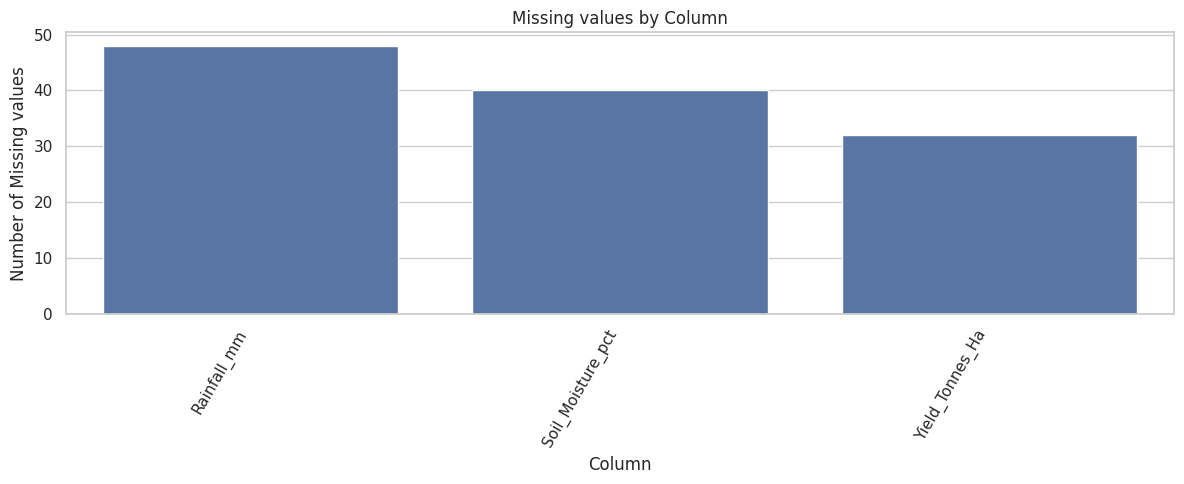

In [12]:
# Visualize missing values
plt.figure(figsize=(12,5))
missing_plot = missing[missing>0]
if len(missing_plot)>0:
  sns.barplot(x=missing_plot.index, y=missing_plot.values)
  plt.xticks(rotation=60, ha='right')
  plt.ylabel("Number of Missing values")
  plt.xlabel("Column")
  plt.title("Missing values by Column")
  plt.tight_layout()
  plt.show()
else:
  print("No missing values found.")

In [13]:
# Duplicate records

duplicate_count= df.duplicated().sum()
print("Number of duplicate rows:",duplicate_count)

Number of duplicate rows: 0


In [14]:
# Remove Duplicate rowes
df = df.drop_duplicates().reset_index(drop = True)
print("Shape after removing duplicates:",df.shape)

Shape after removing duplicates: (4000, 28)


In [15]:
# Check data types again
df.dtypes

,0
Farm_ID,object
State,object
District,object
Crop,object
Season,object
Farm_Area_Hectares,float64
Rainfall_mm,float64
Avg_Temperature_C,float64
Humidity_pct,float64
Sunlight_Hours_Day,float64


In [16]:
# Checking Unique values for categorical columns
categorial_columns = df.select_dtypes(include="object").columns

for col in categorial_columns:
  print(f"\n{col}:")
  print(df[col].nunique(),"unique values")
  print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [17]:
# Checking missing Values after duplicate removel
df.isnull().sum().sort_values(ascending=False).head(10)

,0
Rainfall_mm,48
Soil_Moisture_pct,40
Yield_Tonnes_Ha,32
Farm_ID,0
Crop,0
District,0
Farm_Area_Hectares,0
Season,0
Avg_Temperature_C,0
Humidity_pct,0


In [18]:
# Replacing missing values
numeric_columns = df.select_dtypes(include=np.number).columns

for col in numeric_columns:
  if df[col].isnull().sum()> 0:
    df[col]= df[col].fillna(df[col].median())
print("Remaining missing values:", df.isnull().sum().sum())




Remaining missing values: 0


In [19]:
# Numerical and categorical columns
numeric_columns = df.select_dtypes(include = np.number).columns.tolist()
categorical_columns = df.select_dtypes(include = "object").columns.tolist()

print("Numerical columns:")
print(numeric_columns)

print("\nCategorical columna:")
print(categorical_columns)


Numerical columns:
['Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha', 'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Yield_Tonnes_Ha', 'Production_Tonnes', 'Market_Price_INR_Tonne', 'Total_Cost_INR', 'Revenue_INR', 'Profit_INR', 'Water_Used_m3', 'Water_Efficiency_t_per_1000m3', 'Disease_Pest_Risk_pct']

Categorical columna:
['Farm_ID', 'State', 'District', 'Crop', 'Season', 'Irrigation_Method']


#6. Statistical Analysis


In [20]:
#Descriptive statistics
stats = df[numeric_columns].describe().T
stats["range"] = stats["max"]- stats["min"]
stats["IQR"] = stats["75%"]- stats["25%"]

stats

,count,mean,std,min,25%,50%,75%,max,range,IQR
Farm_Area_Hectares,"4,000.00",7.89,4.22,0.50,4.26,7.89,11.65,15.00,14.50,7.39
Rainfall_mm,"4,000.00",600.92,287.19,80.00,371.58,582.00,831.98,"1,395.20","1,315.20",460.40
Avg_Temperature_C,"4,000.00",26.82,3.82,16.20,23.90,26.90,29.60,39.70,23.50,5.70
Humidity_pct,"4,000.00",63.21,11.96,25.00,54.77,63.00,71.90,95.00,70.00,17.13
Sunlight_Hours_Day,"4,000.00",7.32,1.12,3.50,6.60,7.30,8.10,11.00,7.50,1.50
Soil_pH,"4,000.00",6.70,0.64,5.20,6.26,6.69,7.14,8.40,3.20,0.88
Soil_Moisture_pct,"4,000.00",26.51,6.68,8.00,21.80,26.40,31.20,47.00,39.00,9.40
Nitrogen_kg_ha,"4,000.00",120.25,31.22,40.00,98.50,120.10,141.22,220.00,180.00,42.72
Phosphorus_kg_ha,"4,000.00",57.78,17.02,15.00,46.20,57.50,69.40,120.00,105.00,23.20
Potassium_kg_ha,"4,000.00",104.76,27.74,30.00,86.20,105.10,123.60,200.00,170.00,37.40


In [21]:
# Median and Standard deviation

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()

})

statistical_summary

,Mean,Median,Std Dev,Min,Max
Farm_Area_Hectares,7.89,7.89,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,"1,395.20"
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [22]:
# Seasonal descriptive summary

season_summary =df.groupby("Season")[numeric_columns].agg(["mean","median","std"])
season_summary

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct              \
                    mean median  std         mean median  std   
Season                                                          
Kharif             28.45  28.50 2.51        71.81  71.90 8.86   
Rabi               23.49  23.50 2.46        57.89  58.10 9.00   
Zaid               31.04  31.00 2.55        52.01  52.35 9.05   

       Sunlight_Hours_Day             Soil_pH             Soil_Moisture_pct  \
                     mean median  std    mean median  std              mean   
Season                                                                        
Kharif               6.79   6.80 0.98    6.73   6.73 0.64             31.15   
Rabi                 7.59   7.60 1.00    6.67   6.67 0.64             24.07   
Zaid                 8.18   8.20 1.05    6.69   6.66 0.64             19.28   

                   Nitrogen_kg_ha              Phosphorus_kg_ha               \
       median  std           mean median   std             mean median   std   
Season                                                                         
Kharif  31.10 5.04         120.02 119.80 31.18            58.10  57.40 17.15   
Rabi    24.00 4.94         120.40 120.30 31.10            57.31  57.70 17.12   
Zaid    19.10 4.94         120.53 120.15 31.70            58.13  57.45 16.29   

       Potassium_kg_ha              Fertilizer_kg_ha               \
                  mean median   std             mean median   std   
Season                                                              
Kharif          105.30 104.80 27.03           187.08 188.20 60.82   
Rabi            103.93 104.80 28.87           185.41 185.30 59.95   
Zaid            105.42 106.30 26.66           184.64 183.95 59.47   

       Pesticide_Litre_ha             Seed_Quality_Score              \
                     mean median  std               mean median  std   
Season                                                                 
Kharif               5.08   5.18 1.96               0.82   0.82 0.10   
Rabi                 5.02   5.02 1.99               0.83   0.84 0.10   
Zaid                 5.17   5.19 1.99               0.82   0.83 0.10   

       Yield_Tonnes_Ha              Production_Tonnes                \
                  mean median   std              mean median    std   
Season                                                                
Kharif            5.63   1.94 14.39             46.31  13.24 135.70   
Rabi              5.04   1.67 12.75             41.49  11.08 121.90   
Zaid              4.64   1.46 11.27             38.89   9.97 112.00   

       Market_Price_INR_Tonne                     Total_Cost_INR             \
                         mean    median       std           mean     median   
Season                                                                        
Kharif              44,850.91 25,793.00 30,301.56     531,804.41 524,840.00   
Rabi                44,747.97 26,041.00 30,309.56     513,836.58 506,733.00   
Zaid                44,212.03 25,749.50 30,086.23     543,976.73 534,833.00   

                  Revenue_INR                       Profit_INR             \
              std        mean     median        std       mean     median   
Season                                                                      
Kharif 298,487.69  710,719.06 520,196.00 708,710.37 178,914.65  38,808.00   
Rabi   288,386.89  601,526.05 438,156.00 584,545.52  87,689.47  -3,187.00   
Zaid   297,576.86  519,171.90 373,700.50 509,524.55 -24,804.82 -62,144.00   

                  Water_Used_m3             

<function matplotlib.pyplot.show(close=None, block=None)>

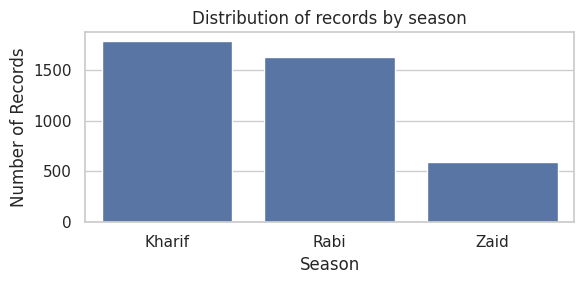

In [23]:
# Univariate: Season- distributation
plt.figure(figsize=(6,3))
sns.countplot(data= df, x="Season")
plt.title("Distribution of records by season")
plt.xlabel("Season")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show

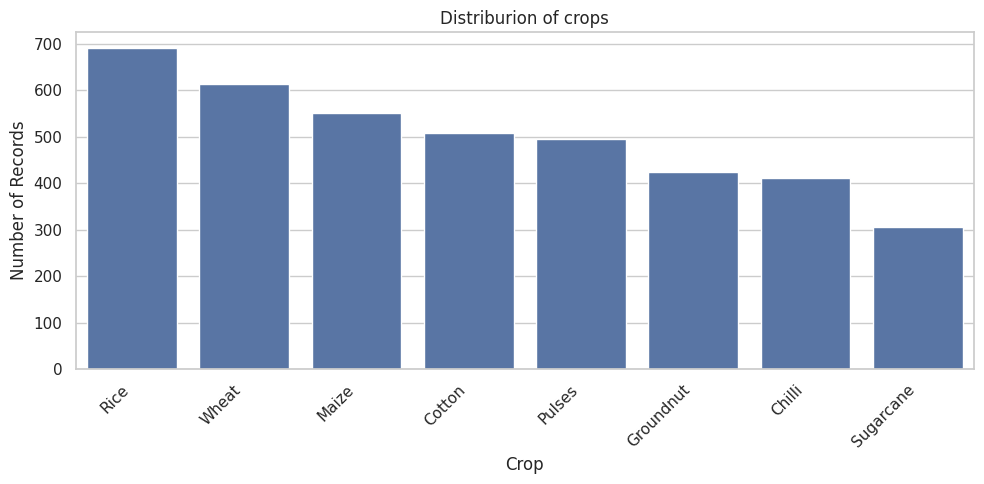

In [24]:
# Univariata: Crop distribution
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Crop",order=df["Crop"].value_counts().index)
plt.xticks(rotation= 45,ha="right")
plt.title("Distriburion of crops")
plt.xlabel("Crop")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

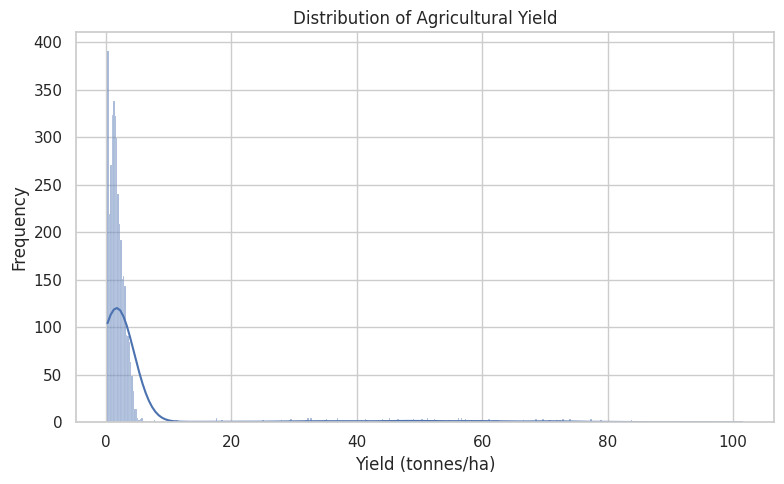

In [25]:
# Univariate: Yield distribution
#here "Yield_Tonnes_Ha" means Yield tonnes per hacteare
plt.figure(figsize=(8,5))
sns.histplot(data = df, x="Yield_Tonnes_Ha",kde = True)
plt.title("Distribution of Agricultural Yield")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


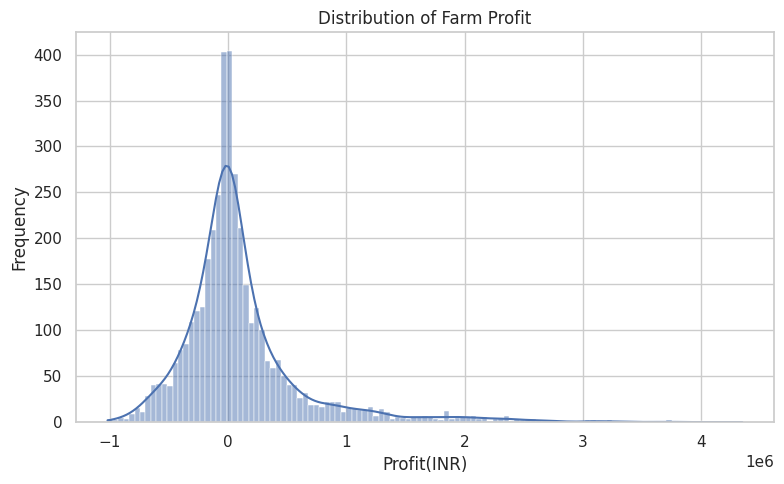

In [26]:
from pandas.tseries import frequencies
# Univariate: Profit Distribution
plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Profit_INR",kde=True)
plt.title("Distribution of Farm Profit")
plt.xlabel("Profit(INR)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

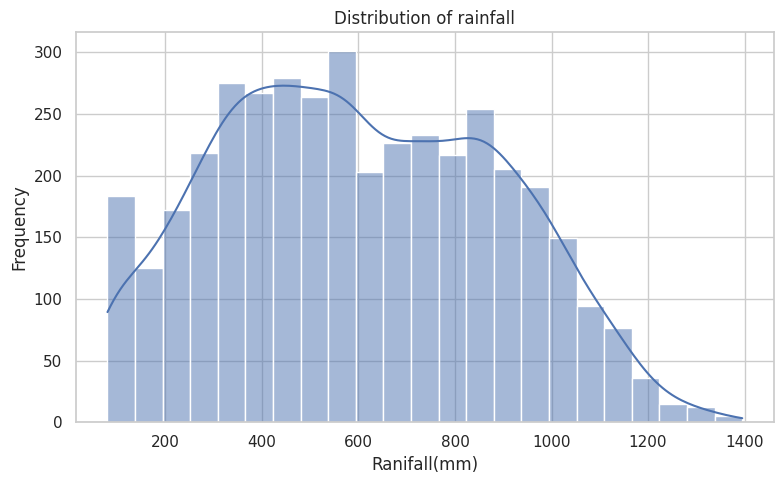

In [27]:
# Univariate: Rainfall Distribution

plt.figure(figsize=(8,5))
sns.histplot(data=df,x="Rainfall_mm",kde=True)
plt.title("Distribution of rainfall")
plt.xlabel("Ranifall(mm)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

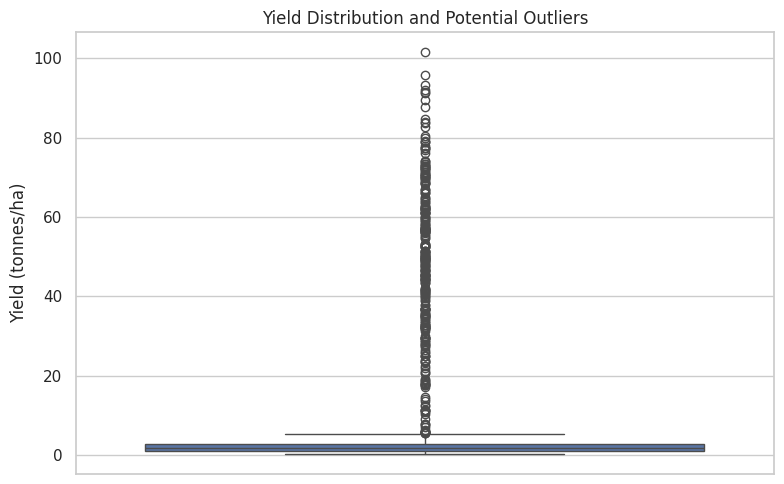

In [28]:
# Boxplot for yield
plt.figure(figsize=(8,5))
sns.boxplot(data=df,y="Yield_Tonnes_Ha")
plt.title("Yield Distribution and Potential Outliers")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show

#7. Outlier Analysis
Investigate potential outliers using Statical and visual methods.

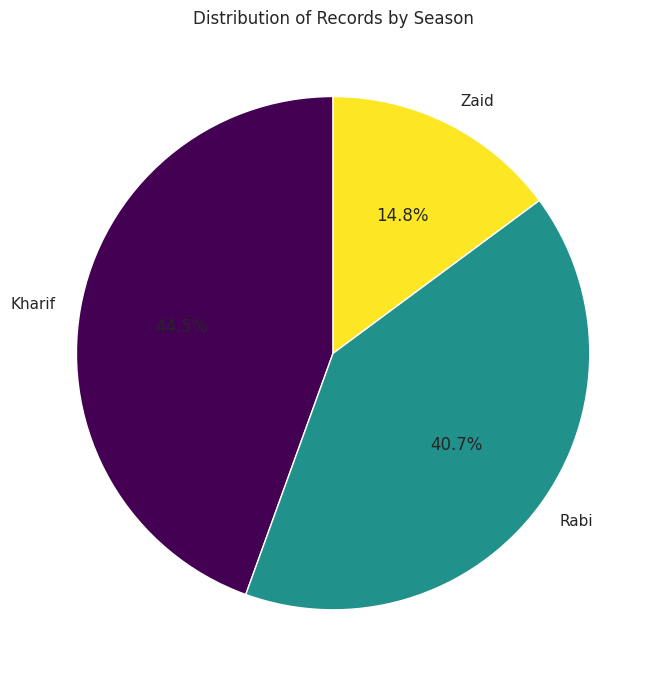

In [29]:
#Univariate : Season distributions(Pie Chart)
plt.figure(figsize=(7,7))
df['Season'].value_counts().plot.pie(autopct = '%1.1f%%',startangle =90,cmap='viridis')
plt.title('Distribution of Records by Season')
plt.ylabel('') # hide the defaul 'Season' label on the y-axis
plt.tight_layout()
plt.show()

In [30]:
# IQR_based outlier summary for numerical columns
outlier_summary=[]

for col in numeric_columns:
  q1=df[col].quantile(0.25)
  q3=df[col].quantile(0.75)
  iqr = q3-q1
  lower = q1 -1.5 *iqr
  upper = q3 + 1.5 *iqr
  count= ((df[col] < lower) | (df[col]>upper)).sum()

  outlier_summary.append({
      "Column":lower,
      "Lower_Bound":lower,
      "Upper_Bound":upper,
      "Outlier_Count": count,
      "Outlier_Percentage": round(count/len(df) * 100, 2)


  })
outlier_summary = pd.DataFrame(outlier_summary).sort_values(
  "Outlier_Count", ascending= False
)
outlier_summary






,Column,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
18,"-696,111.00","-696,111.00","763,567.00",404,10.10
14,-23.98,-23.98,53.36,333,8.33
20,-3.57,-3.57,10.38,322,8.05
13,-1.62,-1.62,5.50,302,7.55
19,"-6,072.75","-6,072.75","16,171.25",276,6.90
17,"-736,519.00","-736,519.00","1,780,911.00",240,6.00
9,30.10,30.10,179.70,32,0.80
4,4.35,4.35,10.35,26,0.65
8,11.40,11.40,104.20,16,0.40
10,19.14,19.14,352.04,15,0.38


#8. Bivatiate Analysis
Bivatiate Analysis examin two variable together.

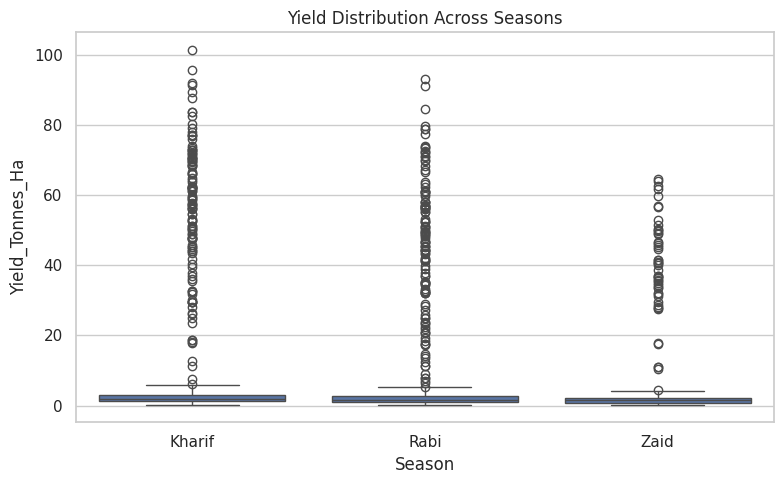

In [31]:
# #Bivariate: Season vs Yield

plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Yield_Tonnes_Ha")
plt.title("Yield Distribution Across Seasons")
plt.xlabel("Season")
plt.ylabel("Yield_Tonnes_Ha")
plt.tight_layout()
plt.show()

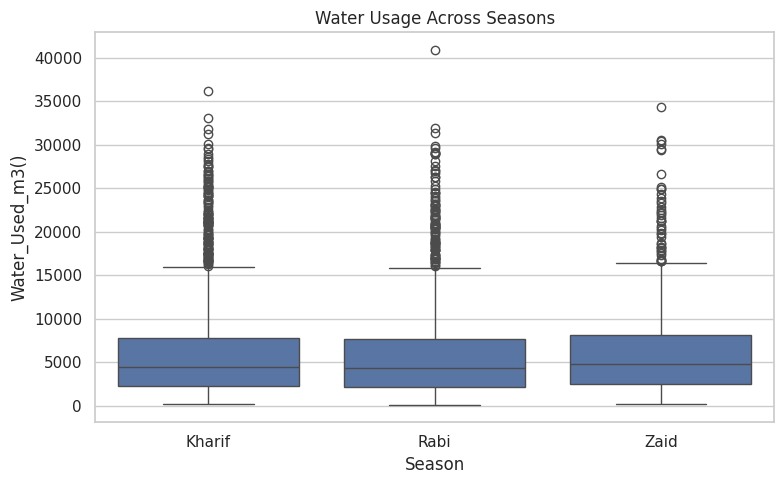

In [32]:
#Bivariate: Season vs Water Usage

plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Water_Used_m3")
plt.title("Water Usage Across Seasons")
plt.xlabel("Season")
plt.ylabel("Water_Used_m3()")
plt.tight_layout()
plt.show()

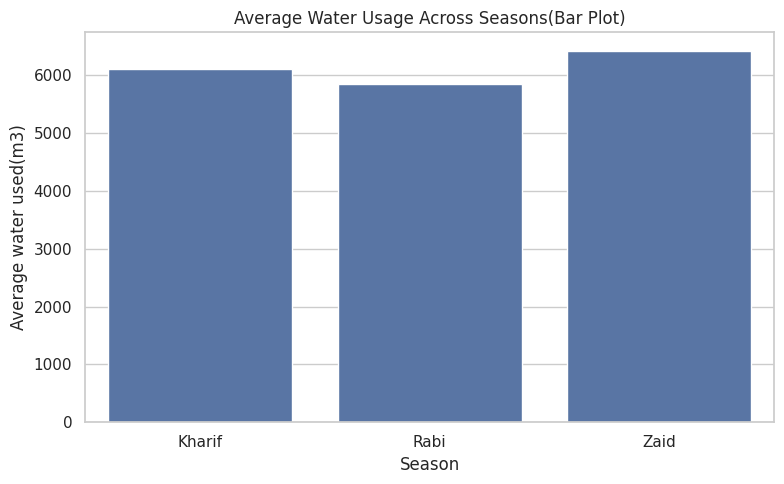

In [33]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Water_Used_m3",errorbar=None)
plt.title("Average Water Usage Across Seasons(Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average water used(m3)")
plt.tight_layout()
plt.show()

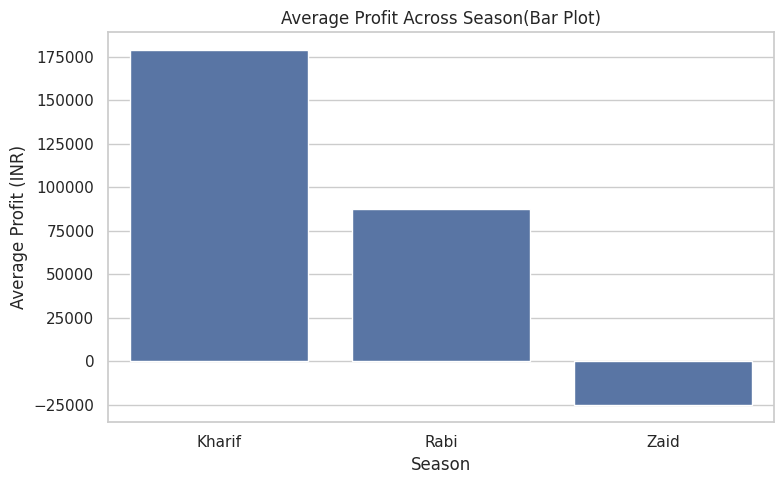

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(data=df,x="Season",y="Profit_INR",errorbar=None)
plt.title("Average Profit Across Season(Bar Plot)")
plt.xlabel("Season")
plt.ylabel("Average Profit (INR)")
plt.tight_layout()
plt.show()

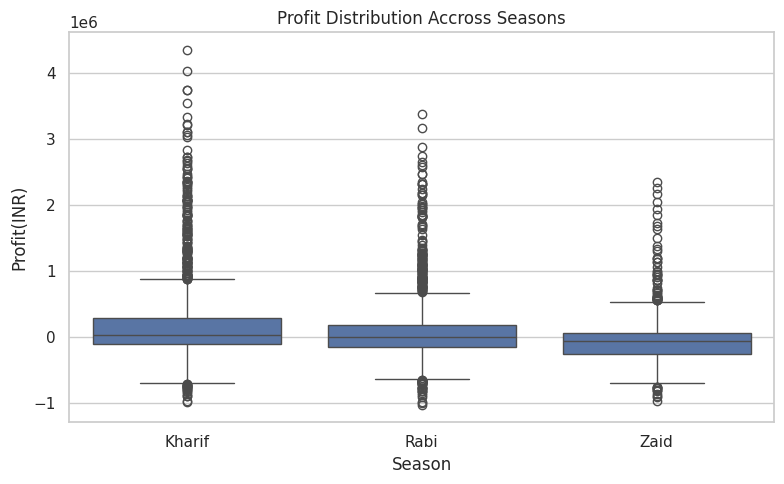

In [35]:
# Bivariate: Season vs Profit

plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Season",y="Profit_INR")
plt.title("Profit Distribution Accross Seasons")
plt.xlabel("Season")
plt.ylabel("Profit(INR)")
plt.tight_layout()
plt.show()

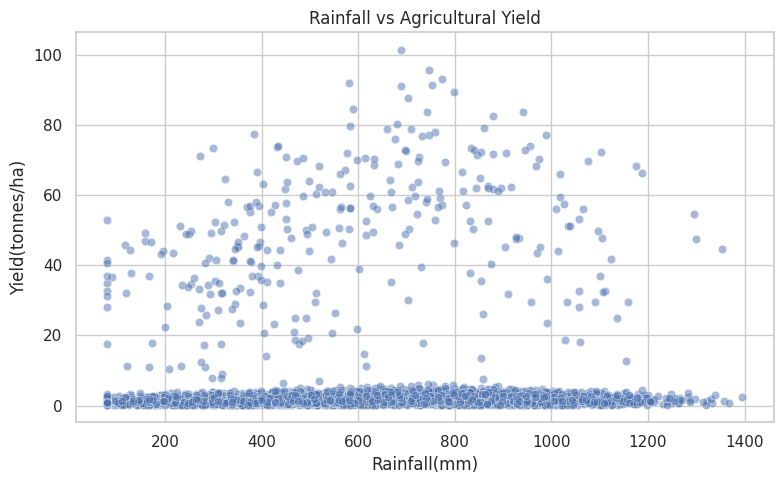

In [36]:
# Bivariate: Rainfall vs Yield

plt.figure(figsize=(8,5))
sns.scatterplot(data=df,x="Rainfall_mm",y="Yield_Tonnes_Ha",alpha=0.5)
plt.title("Rainfall vs Agricultural Yield")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Yield(tonnes/ha)")
plt.tight_layout()
plt.show()


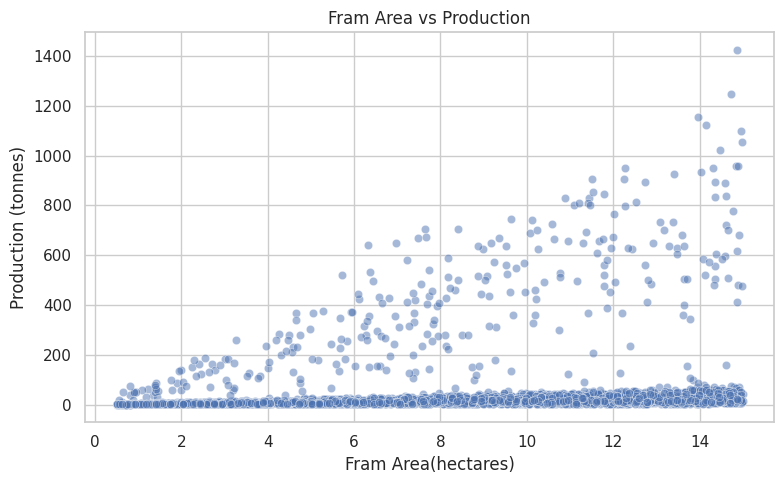

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x="Farm_Area_Hectares",y="Production_Tonnes",alpha=0.5)
plt.title("Fram Area vs Production")
plt.xlabel("Fram Area(hectares)")
plt.ylabel("Production (tonnes)")
plt.tight_layout()
plt.show()

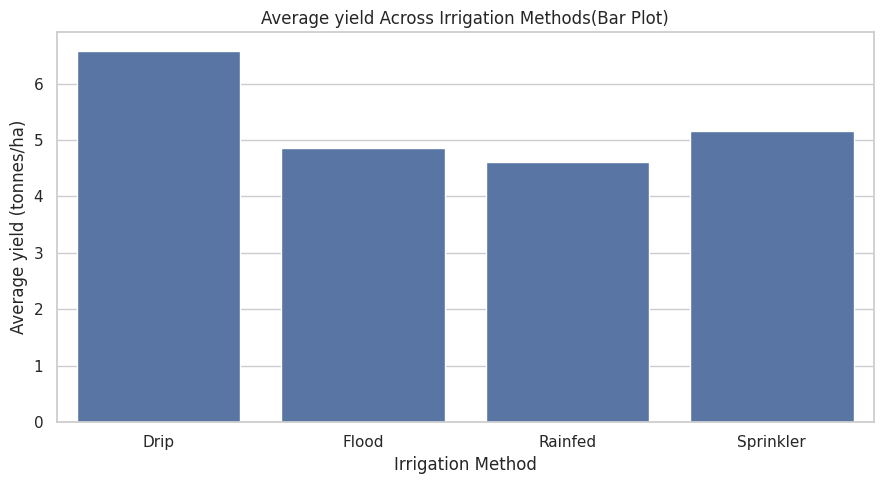

In [38]:
plt.figure(figsize=(9,5))
sns.barplot(data=df,x="Irrigation_Method",y="Yield_Tonnes_Ha",errorbar=None)
plt.title("Average yield Across Irrigation Methods(Bar Plot)")
plt.xlabel("Irrigation Method")
plt.ylabel("Average yield (tonnes/ha)")
plt.tight_layout()
plt.show()

#9. Multivariate Analysis
Multivariate analysis examins more than two variable together.
Using multivariate plot we can analyise how season interacts with other dimention such as crop, region, environmental conditions, resource usage or economic performance.

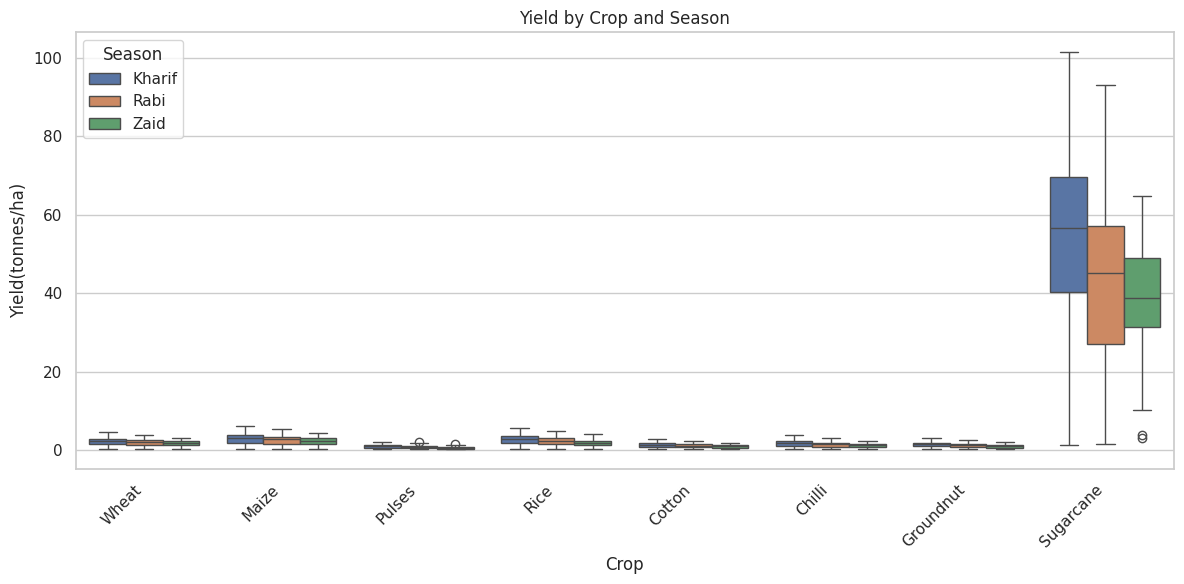

In [39]:
#Multivariate: Season, Crop and yield

plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Crop", y="Yield_Tonnes_Ha",hue="Season")
plt.xticks(rotation=45,ha="right")
plt.title("Yield by Crop and Season")
plt.xlabel("Crop")
plt.ylabel("Yield(tonnes/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

##Multivariate: Pair Plot of Key Environmental and Performance Metrics by Season

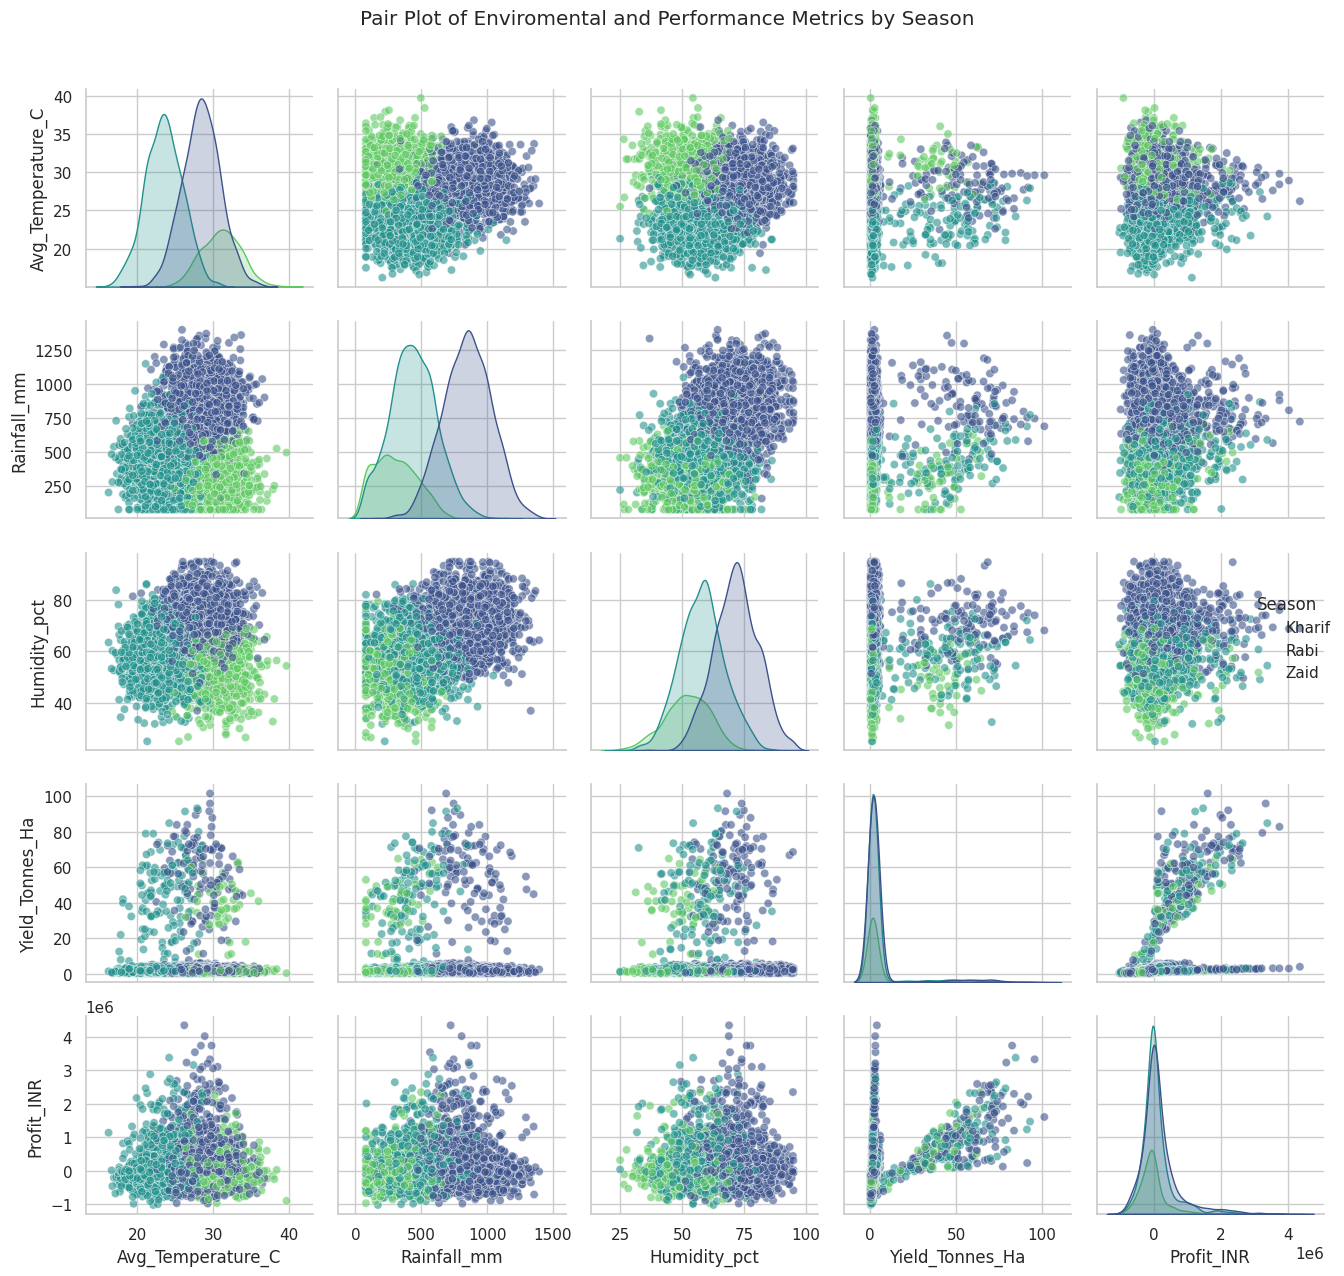

In [40]:
selected_column= ['Avg_Temperature_C','Rainfall_mm','Humidity_pct','Yield_Tonnes_Ha','Profit_INR','Season']
sns.pairplot(df[selected_column],hue= 'Season',palette='viridis', plot_kws={'alpha':0.6})
plt.suptitle("Pair Plot of Enviromental and Performance Metrics by Season",y=1.02)# Adjust suptitle position
plt.tight_layout()
plt.show()

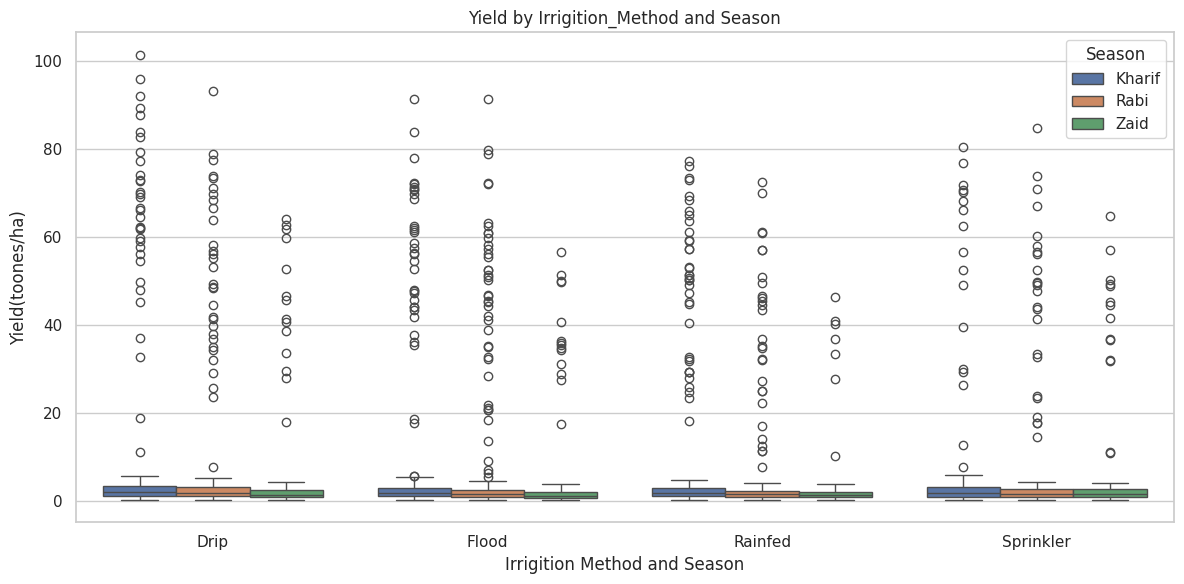

In [41]:
# Multivariate: Season, Irrigation and yield

plt.figure(figsize=(12,6))
sns.boxplot(data=df,x="Irrigation_Method",y="Yield_Tonnes_Ha",hue="Season")
plt.title("Yield by Irrigition_Method and Season")
plt.xlabel("Irrigition Method and Season")
plt.ylabel("Yield(toones/ha)")
plt.legend(title="Season")
plt.tight_layout()
plt.show()

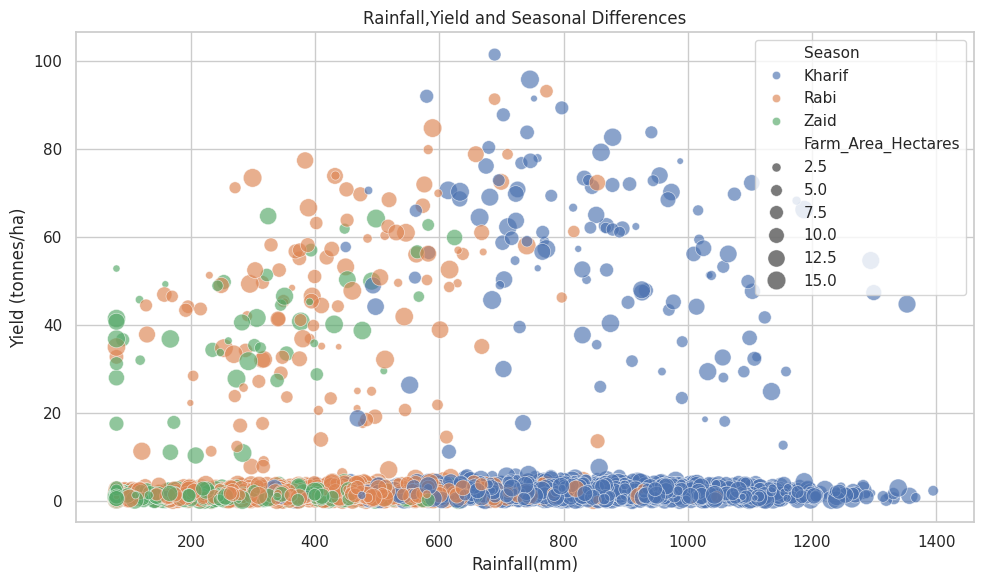

In [42]:
#Multivariate: Rainfall, Yield and season

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Rainfall_mm",
    y="Yield_Tonnes_Ha",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20,180),
    alpha= 0.65


)

plt.title("Rainfall,Yield and Seasonal Differences")
plt.xlabel("Rainfall(mm)")
plt.ylabel("Yield (tonnes/ha)")
plt.tight_layout()
plt.show()


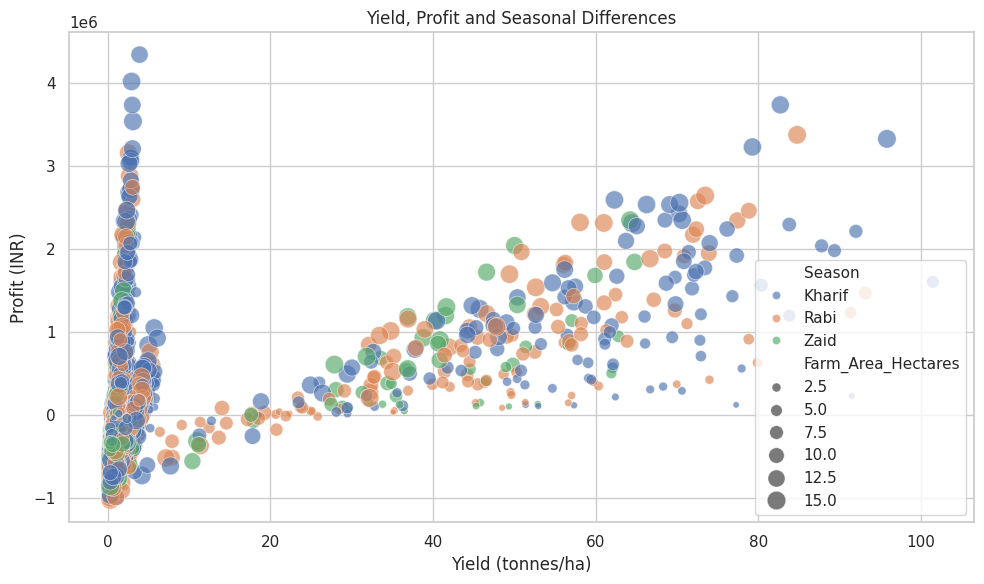

In [43]:
#Multivariate: Profit,yield and season

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="Yield_Tonnes_Ha",
    y="Profit_INR",
    hue="Season",
    size="Farm_Area_Hectares",
    sizes=(20,180),
    alpha=0.65
)
plt.title("Yield, Profit and Seasonal Differences")
plt.xlabel("Yield (tonnes/ha)")
plt.ylabel("Profit (INR)")
plt.tight_layout()
plt.show()

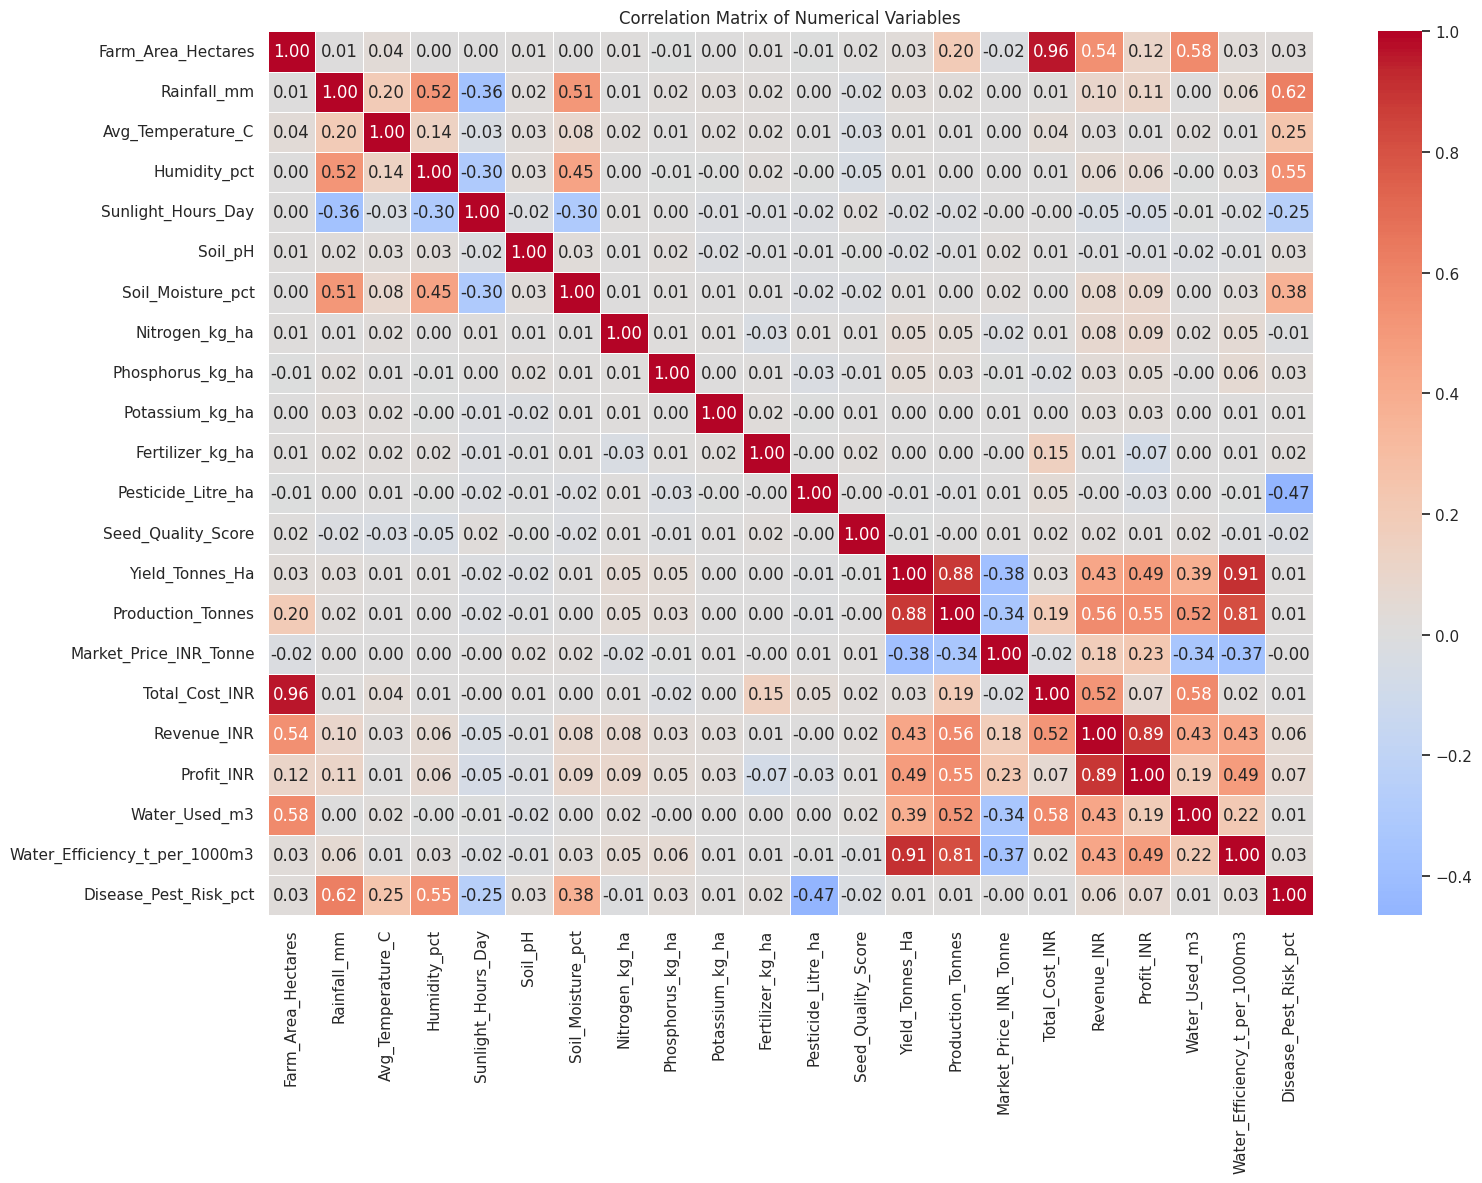

In [48]:
#Correlation heatmap for numerical varibles

plt.figure(figsize=(16,12))
corr= df[numeric_columns].corr(numeric_only=True)

sns.heatmap(
    corr,
    annot= True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5

)
plt.title("Correlation Matrix of Numerical Variables")
plt.tight_layout()
plt.show()

Seasonal Comparison

In [51]:
# General seasonal summary

season_metrics= df.groupby("Season").agg(
    Records=("Farm_ID","count"),
    Average_Yield=("Yield_Tonnes_Ha","mean"),
    Total_Production=("Production_Tonnes","sum"),
    Average_Profit=("Profit_INR","mean"),
    Total_Profit=("Profit_INR","sum"),
    Average_Water_Used=("Water_Used_m3","mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1779,5.63,"82,387.61","178,914.65",318289158,"6,102.20"
Rabi,1627,5.04,"67,498.88","87,689.47",142670768,"5,846.99"
Zaid,594,4.64,"23,098.35","-24,804.82",-14734066,"6,419.89"


In [54]:
#Compare crop performance within each season

crop_season_summary=(
    df.groupby(["Season","Crop"])
      .agg(
          Average_Yield=("Yield_Tonnes_Ha","mean"),
          Average_Profit=("Profit_INR","mean"),
          Average_Water_Efficiency=("Water_Efficiency_t_per_1000m3","mean")
      )
      .round(2)
      .sort_values(["Season","Average_Yield"],ascending=[True,False])
)
crop_season_summary

Average_Yield  Average_Profit  Average_Water_Efficiency
Season Crop                                                              
Kharif Sugarcane          53.46    1,000,790.81                     36.00
       Maize               2.97      -39,332.67                      6.05
       Rice                2.70      -64,903.40                      2.17
       Wheat               2.25     -105,871.87                      4.76
       Chilli              1.73      954,380.42                      3.26
       Groundnut           1.48      108,265.44                      3.58
       Cotton              1.37      216,999.55                      2.13
       Pulses              1.04       43,338.90                      3.35
Rabi   Sugarcane          43.29      731,612.86                     27.92
       Maize               2.60      -89,133.40                      5.46
       Rice                2.32      -98,427.87                      1.84
       Wheat               2.06     -119,954.57                      4.69
       Chilli              1.47      638,572.50                      2.89
       Groundnut           1.23       10,416.54                      2.90
       Cotton              1.20      107,343.59                      1.94
       Pulses              0.88      -14,309.14                      2.70
Zaid   Sugarcane          38.42      583,635.80                     23.39
       Maize               2.29     -194,049.17                      4.75
       Rice                1.90     -227,239.34                      1.53
       Wheat               1.75     -193,208.95                      4.02
       Chilli              1.20      448,659.09                      2.20
       Groundnut           1.04      -68,872.50                      2.47
       Cotton              0.96      -53,925.34                      1.49
       Pulses              0.67     -139,227.81                      1.95

Question1:  Which crop requir the most water?


        Crop  Water_Used_m3
0     Chilli       4,577.47
1     Cotton       5,410.86
2  Groundnut       3,459.54
3      Maize       4,377.78
4     Pulses       2,833.67
5       Rice      10,920.22
6  Sugarcane      13,897.70
7      Wheat       4,054.40


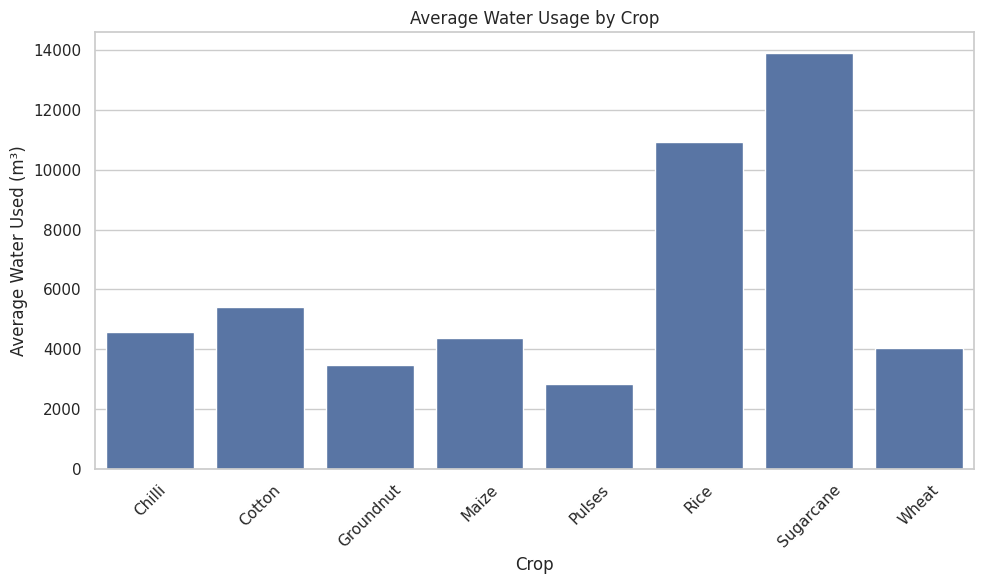

In [60]:

# Average water usage by crop

water_require_crop = df.groupby("Crop")["Water_Used_m3"].mean().reset_index()

print(water_require_crop)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=water_require_crop,
    x="Crop",
    y="Water_Used_m3"
)

plt.title("Average Water Usage by Crop")
plt.xlabel("Crop")
plt.ylabel("Average Water Used (m³)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The analysis shows that sugarcane requires the most water, followed by rice, cotton, chilli, maize, wheat, groundnut, and pulses. This indicates that water requirements vary significantly across crops, so farmers can use this information to plan irrigation and water resources more efficiently.

Question2: Is fertilizer usage related to crop yeild?

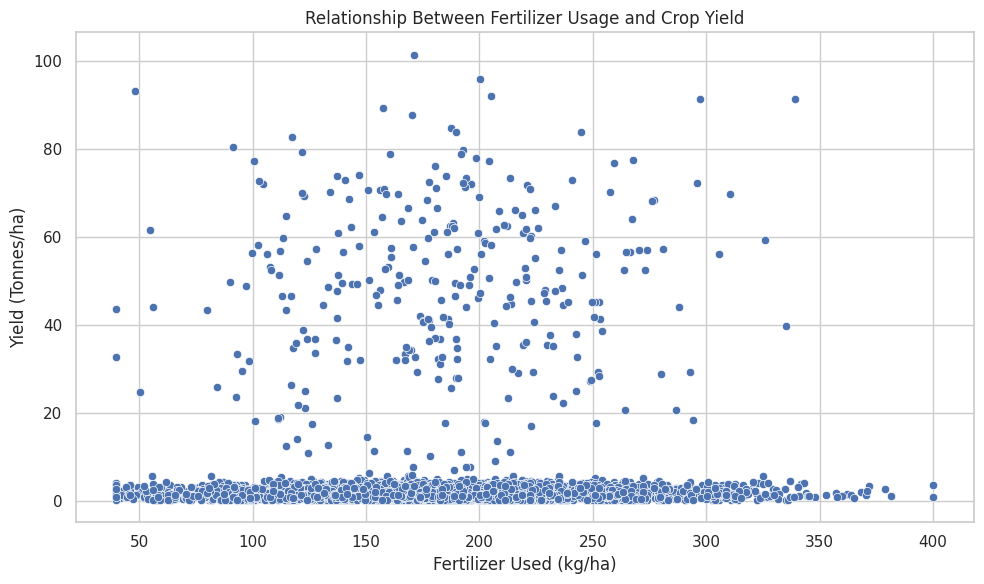

In [61]:

# Relationship between fertilizer usage and yield

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Fertilizer_kg_ha",
    y="Yield_Tonnes_Ha"
)

plt.title("Relationship Between Fertilizer Usage and Crop Yield")
plt.xlabel("Fertilizer Used (kg/ha)")
plt.ylabel("Yield (Tonnes/ha)")

plt.tight_layout()
plt.show()

The analysis shows the relationship between fertilizer usage and crop yield. It helps us understand whether using more fertilizer is associated with higher yield and gives an idea of how fertilizer can affect overall agricultural productivity.

Question3: Which states generate the highest profit?

            State  Profit_INR
4     Maharashtra    69339574
5          Punjab    65836408
2       Karnataka    58397522
1         Gujarat    57373299
6      Tamil Nadu    57106203
7       Telangana    56156082
3  Madhya Pradesh    43159856
0  Andhra Pradesh    38856916


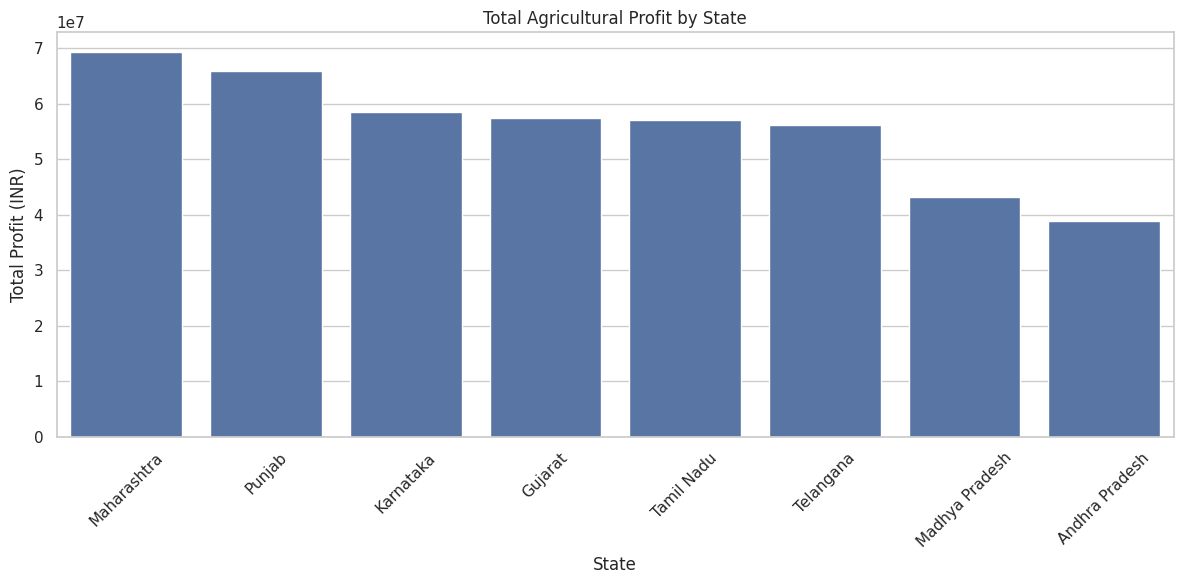

In [62]:

# Total profit by state

profit_by_region = df.groupby("State")["Profit_INR"].sum().reset_index()

profit_by_region = profit_by_region.sort_values(
    by="Profit_INR",
    ascending=False
)

print(profit_by_region)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=profit_by_region,
    x="State",
    y="Profit_INR"
)

plt.title("Total Agricultural Profit by State")
plt.xlabel("State")
plt.ylabel("Total Profit (INR)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

The analysis shows that Maharashtra generates the highest agricultural profit, followed by Punjab, Karnataka, Gujarat, Tamil Nadu, Madhya Pradesh, and Andhra Pradesh. This highlights significant differences in profitability across states and can help identify regions with stronger economic performance in agriculture.

# Final Recommendations



*   Farmers should plan water usage carefully, especially for water-intensive crops like sugercane and rice.

*   Fertilizer should be used in the right amount to support good yield while avoiding unnecessary input costs.
*   Farmers can look at the practices followed in high-profit states like Maharashtra, Punjab, and Karnataka for better economic planning.



*   Crop selection and farming decisions should consider yield, resource requirements, and expected profit together.


# Conclusion

* The analysis shows that agricultural performance is different across crops, regions, and resource usage.

* Some crops require much more water, while profitability also varies significantly from one state to another.

* The fertilizer and yield analysis helps us understand how farming inputs may be connected to productivity.




